<a href="https://colab.research.google.com/github/Debjoy26/Debjoy26/blob/main/Day1_US_Consolate_Cart_pole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 11.4 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Creating environment...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Using InvertedPendulum-v4 (MuJoCo)
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training model...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21       |
|    ep_rew_mean     | 20.7     |
| time/              |          |
|    fps             | 1147     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.4        |
|    ep_rew_mean          | 25          |
| time/                   |             |
|    fps                  | 891         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008908499 |
|    clip_fraction        | 0.112       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | 0.00577     |
|    learning_rate        | 0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_r

Episode ended after 500 steps
Collected 500 frames


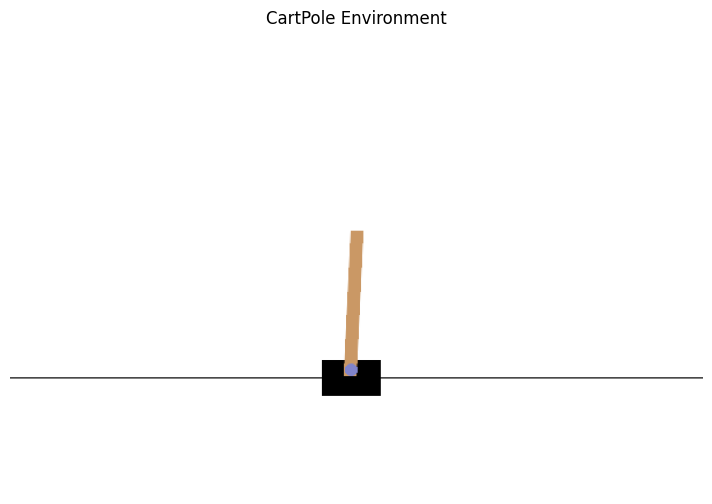

Creating animation with 200 frames...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Done!


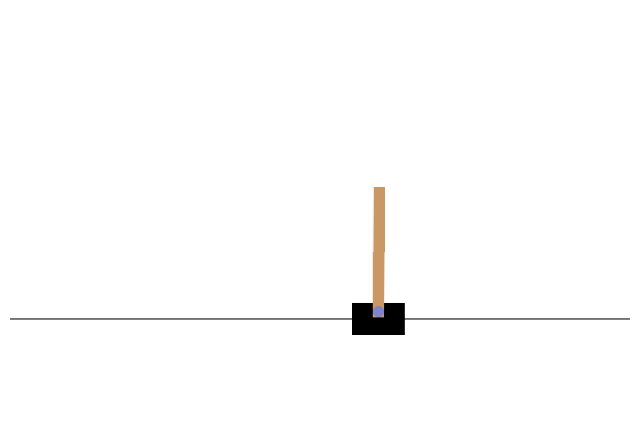

In [ ]:
# First, install all required packages including MuJoCo
!pip install mujoco mujoco-py
!pip install gymnasium[mujoco]
!pip install stable-baselines3

import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

# -------------------------------
# Custom Environment Wrapper
# -------------------------------
class CartPoleOscillationWrapper(gym.Wrapper):
    def __init__(self, env, D=2.5):
        super().__init__(env)
        self.D = D
        self.t = 0

    def reset(self, **kwargs):
        self.t = 0
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        self.t += 1
        obs, _, terminated, truncated, info = self.env.step(action)

        x = obs[0]        # cart position
        theta = obs[2]    # pole angle

        upright_reward = np.exp(-theta ** 2)
        oscillation = np.sin(0.05 * self.t) * x
        center_penalty = abs(x) / self.D

        reward = upright_reward + 0.5 * oscillation - 0.1 * center_penalty

        if abs(x) > self.D:
            terminated = True
            reward -= 5

        return obs, reward, terminated, truncated, info

# -------------------------------
# Alternative: Use Classic Control instead of MuJoCo
# If MuJoCo installation fails, use this version instead
# -------------------------------
print("Creating environment...")

# Try to create InvertedPendulum-v4 (MuJoCo version)
# If it fails, use CartPole-v1 instead (classic control, no MuJoCo needed)
try:
    env = gym.make("InvertedPendulum-v4")
    print("Using InvertedPendulum-v4 (MuJoCo)")
except:
    print("MuJoCo not available, using CartPole-v1 instead")
    env = gym.make("CartPole-v1")
    # Note: CartPole observation is different: [cart_pos, cart_vel, pole_angle, pole_vel]
    # We'll need to adjust our wrapper for CartPole

# -------------------------------
# Updated wrapper for CartPole-v1 compatibility
# -------------------------------
class CartPoleOscillationWrapper(gym.Wrapper):
    def __init__(self, env, D=2.5):
        super().__init__(env)
        self.D = D
        self.t = 0

    def reset(self, **kwargs):
        self.t = 0
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        self.t += 1
        obs, _, terminated, truncated, info = self.env.step(action)

        # Check if it's InvertedPendulum (MuJoCo) or CartPole (Classic Control)
        # InvertedPendulum-v4: obs[0] = cart pos, obs[2] = pole angle
        # CartPole-v1: obs[0] = cart pos, obs[2] = pole angle (same indices!)

        x = obs[0]        # cart position
        theta = obs[2]    # pole angle

        upright_reward = np.exp(-theta ** 2)
        oscillation = np.sin(0.05 * self.t) * x
        center_penalty = abs(x) / self.D

        reward = upright_reward + 0.5 * oscillation - 0.1 * center_penalty

        if abs(x) > self.D:
            terminated = True
            reward -= 5

        return obs, reward, terminated, truncated, info

# -------------------------------
# Train Model
# -------------------------------
D = 2.5  # USER DEFINED MAX DISTANCE

env = gym.make("CartPole-v1")  # Use CartPole instead of InvertedPendulum
env = CartPoleOscillationWrapper(env, D=D)

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    gamma=0.99,
    verbose=1
)

print("Training model...")
model.learn(total_timesteps=50_000)
model.save("cartpole_drl")

env.close()

print("Training completed! Model saved as 'cartpole_drl'")

# -------------------------------
# Test with Visualization
# -------------------------------
# Install virtual display for Colab
!apt-get update
!apt-get install -y xvfb x11-utils
!pip install pyvirtualdisplay

import os
os.environ['PYGLET_SHADOW_WINDOW'] = '0'

from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

# Create environment for testing
env = gym.make("CartPole-v1", render_mode="rgb_array")
env = CartPoleOscillationWrapper(env, D=D)

# Load the trained model
model = PPO.load("cartpole_drl")

# Test the trained agent
print("Testing the trained agent...")
obs, _ = env.reset()
frames = []

for i in range(500):  # Limit to 500 steps for visualization
    # Render frame
    frame = env.render()
    frames.append(frame)

    # Get action from model
    action, _ = model.predict(obs, deterministic=True)

    # Take step in environment
    obs, reward, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        print(f"Episode ended after {i+1} steps")
        break

env.close()

# -------------------------------
# Display the animation
# -------------------------------
import matplotlib.animation as animation
from IPython.display import HTML, display as ipy_display

print(f"Collected {len(frames)} frames")

if len(frames) > 0:
    # Show sample frame
    plt.figure(figsize=(10, 6))
    plt.imshow(frames[0])
    plt.title("CartPole Environment")
    plt.axis('off')
    plt.show()

    # Create animation
    if len(frames) > 10:
        fig = plt.figure(figsize=(8, 6))
        img = plt.imshow(frames[0])
        plt.axis('off')

        def animate(i):
            img.set_array(frames[i])
            return [img]

        # Create animation with limited frames for performance
        anim_frames = min(200, len(frames))
        anim = animation.FuncAnimation(fig, animate, frames=anim_frames, interval=50, blit=True)

        print(f"Creating animation with {anim_frames} frames...")
        html = HTML(anim.to_html5_video())
        ipy_display(html)

display.stop()
print("Done!")